In [83]:
import os
import pathlib
import time
import datetime
import imageio
import scipy
import scipy.linalg
from glob import glob

import tensorflow as tf
import numpy as np 
import tensorflow.keras.backend as K
import tensorflow_addons as tfa

from matplotlib import pyplot as plt
from IPython import display
from termcolor import colored
from tqdm import tqdm
from IPython.display import Image
import PIL
from PIL import ImageDraw
from IPython import display

In [32]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    print(f'setting seed to {seed}')

class CFG:
    IMG_WIDTH = 256
    IMG_HEIGHT = 256
    BATCH_SIZE = 1
    BUFFER_SIZE = 100
    learning_rate = 0.00025
    seed = 7

set_seed(CFG.seed)

setting seed to 7


In [33]:
day_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Day"
night_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Night"

In [36]:
def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.io.decode_jpeg(image)
    return image

def preprocess_image(image_file):
    image = load_image(image_file)
    image = tf.image.resize(image, (CFG.IMG_HEIGHT, CFG.IMG_WIDTH))
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1
    return image

def create_img_dataset(directory, repeat=True, image_extension='jpg'):
    img_list = glob(directory + f'/*{image_extension}')
    dataset = tf.data.Dataset.list_files(img_list)
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if repeat:
        dataset = dataset.repeat()

    dataset = dataset.shuffle(CFG.BUFFER_SIZE)
    dataset = dataset.batch(CFG.BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [37]:
Day_Dataset = create_img_dataset(day_dir)
Night_Dataset = create_img_dataset(night_dir)

Day_eval = create_img_dataset(day_dir, repeat=False)

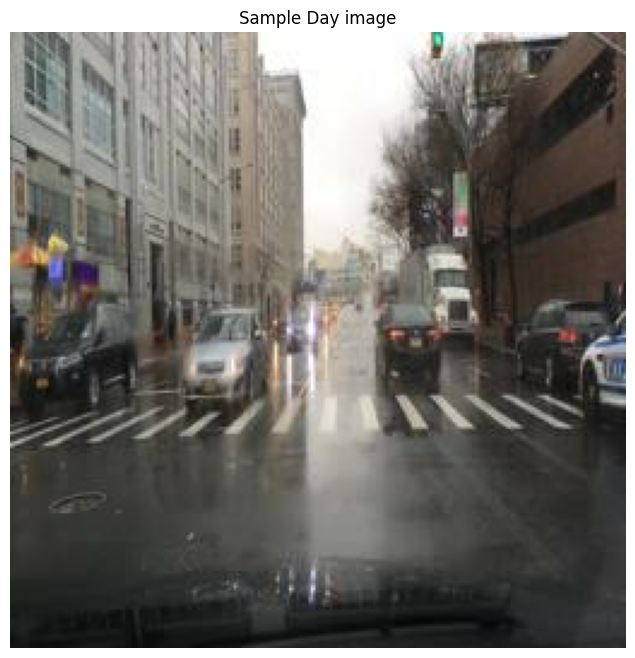

In [38]:
fig, ax = plt.subplots(figsize=(16, 8))
sample = next(iter(Day_Dataset))
plt.imshow((sample[0] * 0.5 + 0.5).numpy())  
plt.title('Sample Day image')
plt.axis('off')
plt.show()

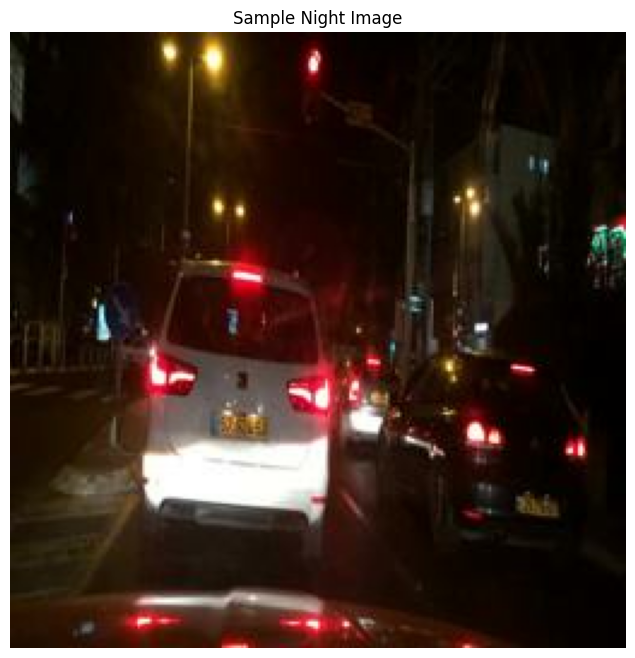

In [40]:
fig, ax = plt.subplots(figsize=(16, 8))
sample = next(iter(Night_Dataset))
plt.imshow((sample[0] * 0.5 + 0.5).numpy())
plt.title("Sample Night Image")
plt.axis("off")
plt.show()

In [41]:
Train_Dataset = tf.data.Dataset.zip((Day_Dataset,Night_Dataset))

In [45]:
conv_init = tf.random_normal_initializer(0., 0.02)
gamma_init = tf.keras.initializers.RandomNormal(0., 0.02)

def downsample(x, filters, name, size=3, strides=2, activation=tf.keras.layers.ReLU()):
    x = tf.keras.layers.Conv2D(filters, size, strides=strides, padding='same',use_bias=False, kernel_initializer=conv_init,name=f"enc_{name}")(x)
    x = tfa.layers.InstanceNormalization(gamma_initializer=gamma_init)(x)
    return activation(x)

def upsample(x, filters, name, size=3, strides=2, activation='relu'):
    x = tf.keras.layers.Conv2DTranspose(filters, size, strides=strides, padding='same',use_bias=False, kernel_initializer=conv_init,name=f"dec_{name}")(x)
    x = tfa.layers.InstanceNormalization(gamma_initializer=gamma_init)(x)
    return tf.keras.layers.Activation(activation)(x)

def residual_block(x, name):
    f = x.shape[-1]
    y = tf.keras.layers.Conv2D(f, 3, padding='same', use_bias=False,kernel_initializer=conv_init,name=f"res_{name}_1")(x)
    y = tf.keras.layers.Activation("relu")(y)
    y = tf.keras.layers.Conv2D(f, 3, padding='same', use_bias=False,kernel_initializer=conv_init,name=f"res_{name}_2")(y)
    return tf.keras.layers.Add()([x, y])

In [48]:
def get_generator_small(res_blocks=3):
    inp = tf.keras.layers.Input((CFG.IMG_WIDTH, CFG.IMG_HEIGHT, 3))

    # smaller filters: 32, 64, 128, 128
    e1 = downsample(inp, 32,  "d1", size=7, strides=1)
    e2 = downsample(e1, 64, "d2")
    e3 = downsample(e2, 128, "d3")
    e4 = downsample(e3, 128, "d4")

    x = e4
    for i in range(res_blocks):
        x = residual_block(x, name=f"r{i+1}")

    u1 = upsample(tf.concat([x, e4], -1), 128, "u1")
    u2 = upsample(tf.concat([u1, e3], -1), 64, "u2")
    u3 = upsample(tf.concat([u2, e2], -1), 32, "u3")

    out = tf.keras.layers.Conv2D(3, 7, padding='same', activation='tanh',
                                 kernel_initializer=conv_init, name="out")(
        tf.concat([u3, e1], -1))
    return tf.keras.Model(inp, out)

# gunakan yang kecil:
day2night_gen = get_generator_small()
night2day_gen = get_generator_small()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.095837176..0.12162544].


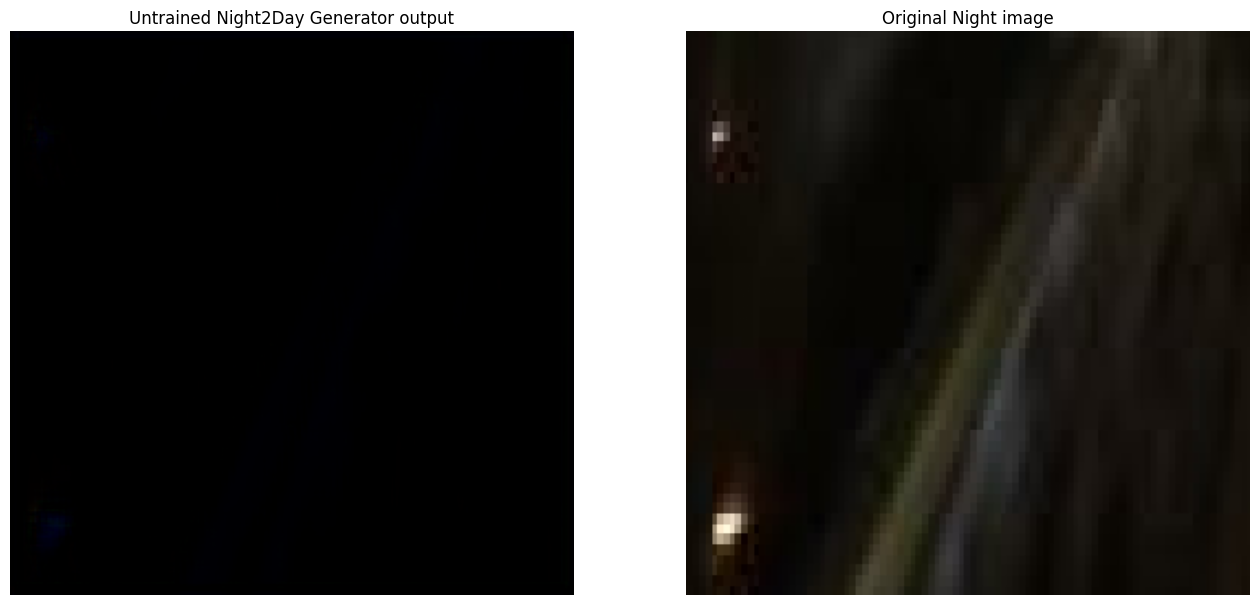

In [49]:
gen_output = night2day_gen(inp_img, training=False)[0]
plt.subplots(1,2,figsize=(16,8))

plt.subplot(1,2,1)
plt.imshow(gen_output.numpy().squeeze())
plt.title('Untrained Night2Day Generator output')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(de_normalize(inp_img[0]))
plt.title('Original Night image')
plt.axis('off')

plt.show()

In [50]:
def PATCH_discriminator(leak=0.2):
    inp = tf.keras.layers.Input((CFG.IMG_WIDTH, CFG.IMG_HEIGHT, 3))
    act = tf.keras.layers.LeakyReLU(leak)

    x = downsample(inp, 64,  "d1", size=4, activation=act)
    x = downsample(x,   128, "d2", size=4, activation=act)
    x = downsample(x,   256, "d3", size=4, activation=act)
    x = downsample(x,   512, "d4", size=4, activation=act)
    x = downsample(x,   512, "d5", size=4, strides=1, activation=act)

    out = tf.keras.layers.Conv2D(1, 4, padding='valid', kernel_initializer=conv_init)(x)
    return tf.keras.Model(inp, out)

day2night_disc = PATCH_discriminator()
night2day_disc = PATCH_discriminator()

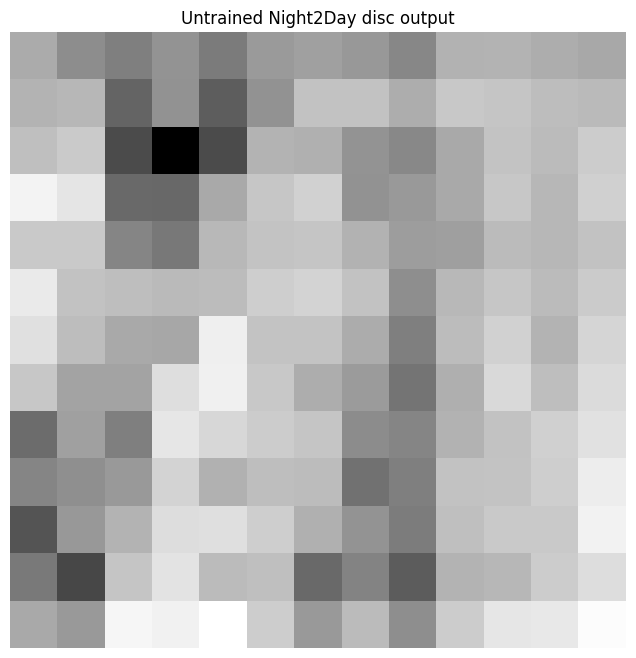

In [51]:
disc_output = day2night_disc(inp_img, training=False)
plt.subplots(1,1,figsize=(8,8))

plt.imshow(disc_output.numpy().mean(axis=0),cmap='gray')
plt.title('Untrained Night2Day disc output')
plt.axis('off')

plt.show()

In [53]:
def discriminator_loss(real, fake):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    return 0.5 * (bce(tf.ones_like(real), real) + bce(tf.zeros_like(fake), fake))

def generator_loss(fake):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    return bce(tf.ones_like(fake), fake)

def cycle_loss(real, cycled, L=10):
    return L * tf.reduce_mean(tf.abs(real - cycled))

def identity_loss(real, same, L=10):
    return 0.5 * L * tf.reduce_mean(tf.abs(real - same))

In [54]:
class CycleGAN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.g_d2n = day2night_gen
        self.g_n2d = night2day_gen
        self.d_d2n = day2night_disc
        self.d_n2d = night2day_disc

    def compile(self, **kwargs):
        super().compile()
        self.opt_g_d2n = tf.keras.optimizers.Adam(CFG.learning_rate, beta_1=0.5)
        self.opt_g_n2d = tf.keras.optimizers.Adam(CFG.learning_rate, beta_1=0.5)
        self.opt_d_d2n = tf.keras.optimizers.Adam(CFG.learning_rate, beta_1=0.5)
        self.opt_d_n2d = tf.keras.optimizers.Adam(CFG.learning_rate, beta_1=0.5)

    def train_step(self, batch):
        day, night = batch

        with tf.GradientTape(persistent=True) as tape:
            fake_night = self.g_d2n(day, training=True)
            fake_day   = self.g_n2d(night, training=True)

            cycled_day   = self.g_n2d(fake_night, training=True)
            cycled_night = self.g_d2n(fake_day,   training=True)

            id_day   = self.g_n2d(day,   training=True)
            id_night = self.g_d2n(night, training=True)

            d_real_night = self.d_d2n(night, training=True)
            d_fake_night = self.d_d2n(fake_night, training=True)
            d_real_day   = self.d_n2d(day, training=True)
            d_fake_day   = self.d_n2d(fake_day, training=True)

            g_d2n_loss = (generator_loss(d_fake_night) +
                          cycle_loss(day, cycled_day) +
                          identity_loss(day, id_day))

            g_n2d_loss = (generator_loss(d_fake_day) +
                          cycle_loss(night, cycled_night) +
                          identity_loss(night, id_night))

            d_d2n_loss = discriminator_loss(d_real_night, d_fake_night)
            d_n2d_loss = discriminator_loss(d_real_day,   d_fake_day)

        self.opt_g_d2n.apply_gradients(zip(tape.gradient(g_d2n_loss, self.g_d2n.trainable_variables),
                                           self.g_d2n.trainable_variables))
        self.opt_g_n2d.apply_gradients(zip(tape.gradient(g_n2d_loss, self.g_n2d.trainable_variables),
                                           self.g_n2d.trainable_variables))
        self.opt_d_d2n.apply_gradients(zip(tape.gradient(d_d2n_loss, self.d_d2n.trainable_variables),
                                           self.d_d2n.trainable_variables))
        self.opt_d_n2d.apply_gradients(zip(tape.gradient(d_n2d_loss, self.d_n2d.trainable_variables),
                                           self.d_n2d.trainable_variables))

        return {
            "gen_D2N_loss": g_d2n_loss,
            "gen_N2D_loss": g_n2d_loss,
            "disc_day_loss": d_n2d_loss,
            "disc_night_loss": d_d2n_loss
        }

In [56]:
#creat a instance of Cycle gan 
gan = CycleGAN()

#complie with the losses 
gan.compile(gen_loss_fn=generator_loss,
            disc_loss_fn=discriminator_loss,
            cycle_loss_fn=calc_cycle_loss,
            identity_loss_fn=identity_loss)

In [57]:
class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, patience=0):
        super(CustomEarlyStopping, self).__init__()
        self.patience = patience
        self.best_weights = None
        
    def on_train_begin(self, logs=None):
        # The number of epoch it has waited when loss is no longer minimum.
        self.wait = 0
        # The epoch the training stops at.
        self.stopped_epoch = 0
        # Initialize the best as infinity.
        self.n2d_loss = np.Inf
        self.d2n_loss = np.Inf

    def on_epoch_end(self, epoch, logs=None): 
        n2d_loss=logs.get('gen_N2D_loss')
        d2n_loss=logs.get('gen_D2N_loss')

        # If both the conditions are met, continue training
        if (np.less(n2d_loss, self.n2d_loss) and np.less(d2n_loss, self.d2n_loss)):
            self.d2n_loss = d2n_loss
            self.n2d_loss = n2d_loss
            self.wait = 0
            # Record the best weights if current results is better (less).
            self.best_weights = self.model.get_weights()
            
        # if above xondition not met, continue training till patiance epochs
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print("Restoring model weights from the end of the best epoch.")
                self.model.set_weights(self.best_weights)
                
    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print("Epoch %05d: early stopping" % (self.stopped_epoch + 1))

In [95]:
EPOCHS = 50

history = {
    'gen_D2N_loss': [],
    'gen_N2D_loss': [],
    'disc_day_loss': [],
    'disc_night_loss': []
}

callbacks = [CustomEarlyStopping(patience=10)]
steps_per_epoch = 400

gan_history = gan.fit(
    Train_Dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

Epoch 1/50
400/400 [==============================] - 315s 786ms/step - gen_D2N_loss: 6.1704 - gen_N2D_loss: 3.4922 - disc_day_loss: 0.5377 - disc_night_loss: 0.4718
Epoch 2/50
400/400 [==============================] - 310s 774ms/step - gen_D2N_loss: 5.6833 - gen_N2D_loss: 3.4106 - disc_day_loss: 0.5252 - disc_night_loss: 0.4748
Epoch 3/50
400/400 [==============================] - 310s 774ms/step - gen_D2N_loss: 5.9129 - gen_N2D_loss: 3.4947 - disc_day_loss: 0.5046 - disc_night_loss: 0.4953
Epoch 4/50
400/400 [==============================] - 310s 774ms/step - gen_D2N_loss: 5.6917 - gen_N2D_loss: 3.6481 - disc_day_loss: 0.5166 - disc_night_loss: 0.4846
Epoch 5/50
400/400 [==============================] - 313s 782ms/step - gen_D2N_loss: 5.9141 - gen_N2D_loss: 3.6350 - disc_day_loss: 0.4994 - disc_night_loss: 0.4852
Epoch 6/50
400/400 [==============================] - 316s 789ms/step - gen_D2N_loss: 5.6576 - gen_N2D_loss: 3.7246 - disc_day_loss: 0.5267 - disc_night_loss: 0.4947
Epoc

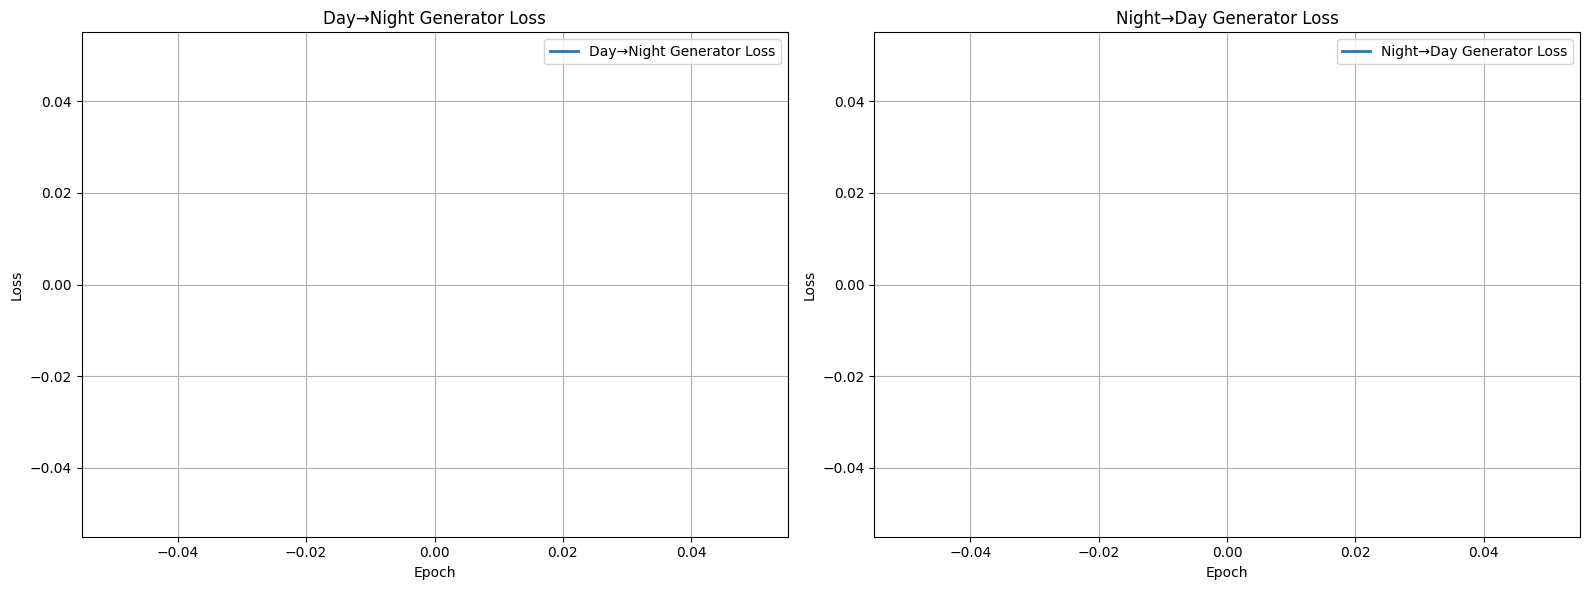

In [96]:
def plot_generator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['gen_D2N_loss']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['gen_D2N_loss'], label='Day→Night Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day→Night Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['gen_N2D_loss'], label='Night→Day Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night→Day Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_generator_loss(history)

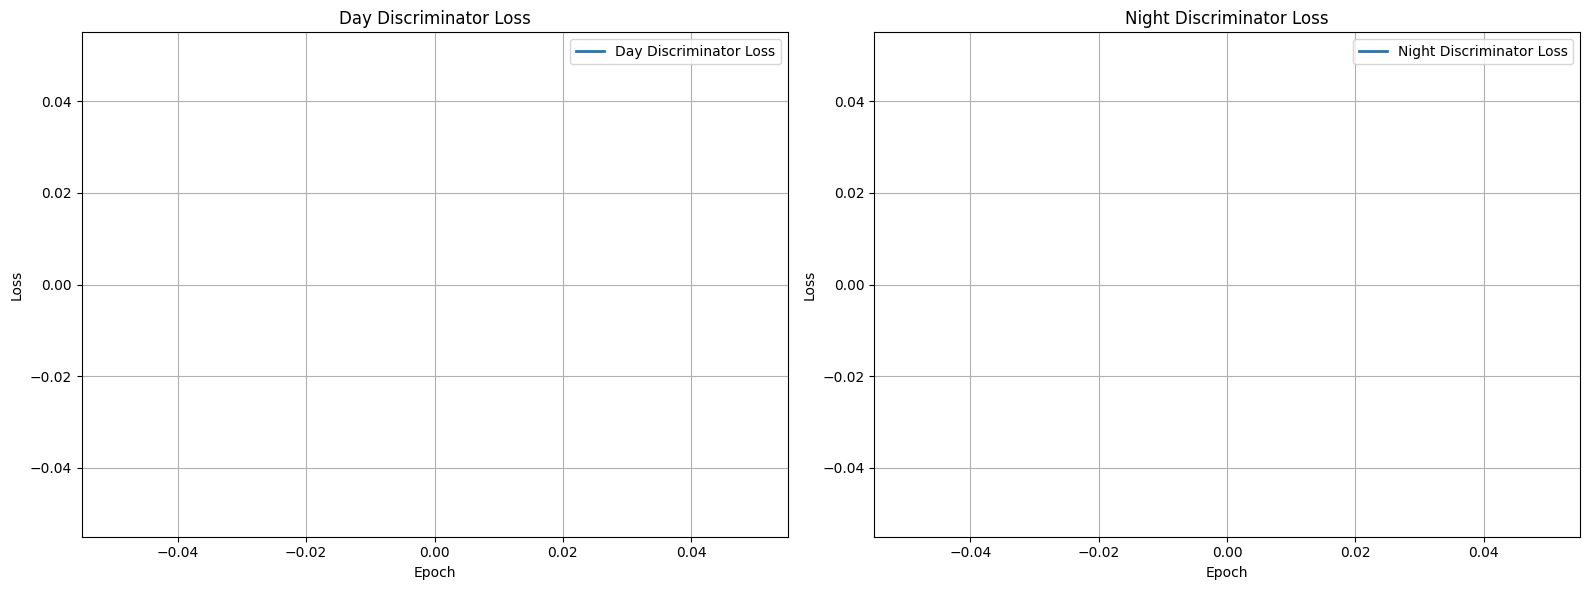

In [97]:
def plot_discriminator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['disc_day_loss']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['disc_day_loss'], label='Day Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['disc_night_loss'], label='Night Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_discriminator_loss(history)

In [98]:
def display_generated_day2night(day2night_gen, day_dataset, num_images=5, start_from=1):
    plt.figure(figsize=(20, 10))
    ssim_scores = []

    # Ambil subset dari dataset sesuai jumlah gambar
    selected_days = day_dataset.skip(start_from - 1).take(num_images)

    for i, real_day in enumerate(selected_days):
        # Jika dataset batched, ambil 1
        if len(real_day.shape) == 4:
            real_day = real_day[0]   # shape: (128,128,3)

        # expand dims → shape: (1,128,128,3)
        real_day_batch = tf.expand_dims(real_day, axis=0)

        # Generate (Day → Night)
        fake_night = day2night_gen(real_day_batch, training=False)

        # Rescale ke [0,1]
        def rescale(x):
            return (x[0] * 0.5 + 0.5).numpy().clip(0, 1)

        real_day_rescaled = rescale(real_day_batch)
        fake_night_rescaled = rescale(fake_night)

        # Hitung SSIM
        ssim_score = tf.image.ssim(real_day_rescaled, fake_night_rescaled, max_val=1.0).numpy()
        ssim_percent = float(ssim_score * 100)
        ssim_scores.append(ssim_percent)

        # === Plotting ===
        plt.subplot(2, num_images, i + 1)
        plt.imshow(real_day_rescaled)
        plt.title("Original Day", fontsize=16)
        plt.axis("off")

        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(fake_night_rescaled)
        plt.title(f"Generated Night\nSSIM: {ssim_percent:.2f}%", fontsize=14)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\nRata-rata SSIM (Day → Night): {np.mean(ssim_scores):.2f}%")
    return ssim_scores

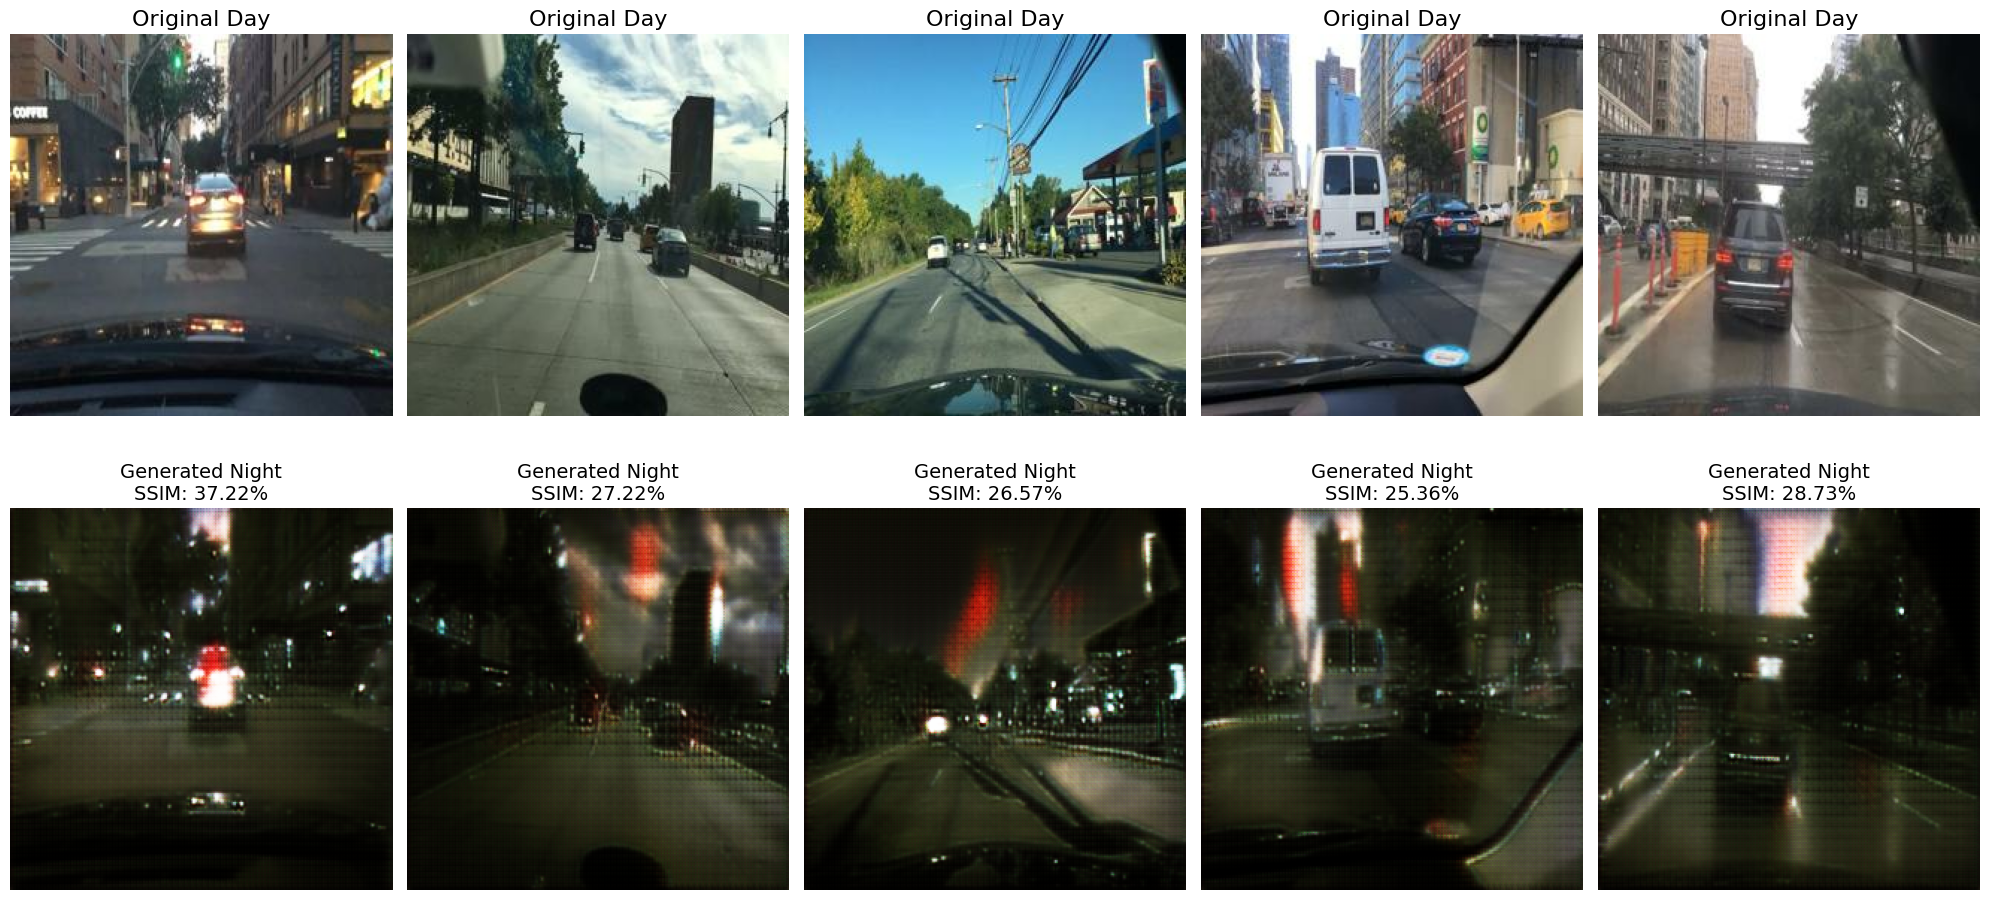


Rata-rata SSIM (Day → Night): 29.02%


[37.215039134025574,
 27.217215299606323,
 26.5683650970459,
 25.362950563430786,
 28.73140275478363]

In [99]:
display_generated_day2night(day2night_gen, Day_eval, num_images=5)

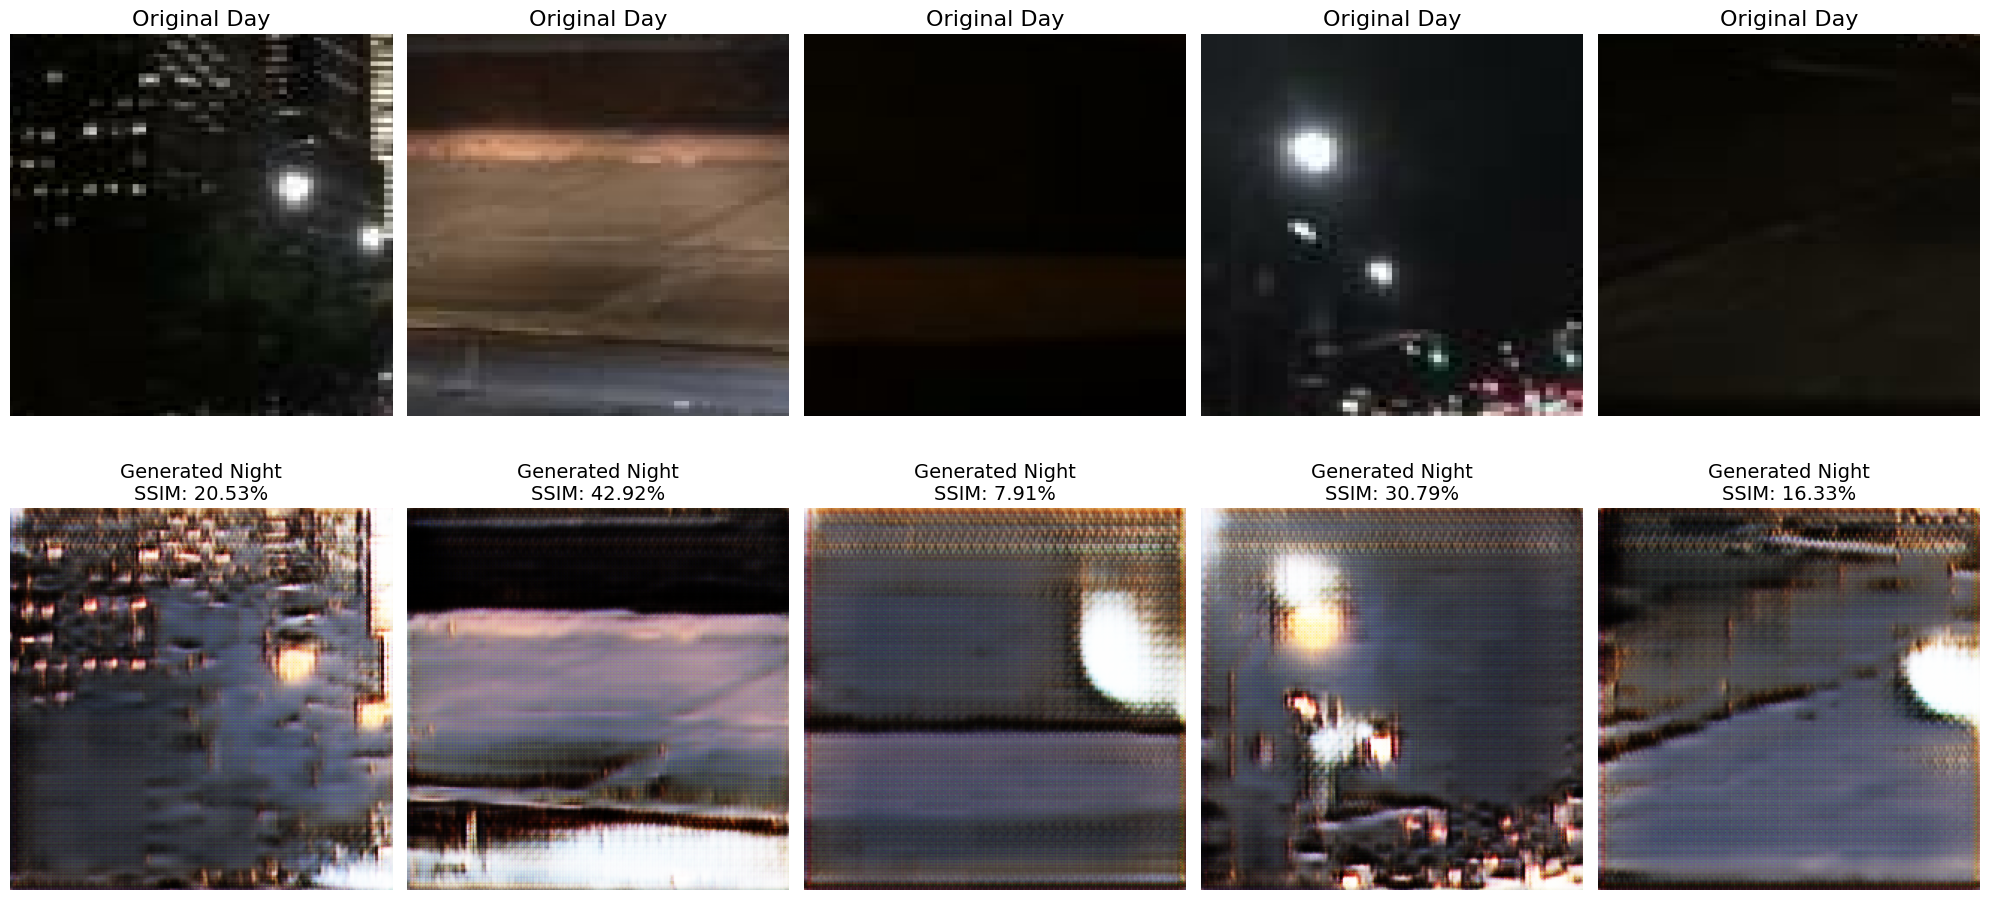


Rata-rata SSIM (Day → Night): 23.70%


[20.534634590148926,
 42.916882038116455,
 7.9149313271045685,
 30.786043405532837,
 16.326819360256195]

In [100]:
display_generated_day2night(night2day_gen, Night_eval, num_images=5)